### Imbort Lib

In [85]:
import numpy as np
import random
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report , confusion_matrix
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.model_selection import train_test_split

### Dataset Path

In [86]:
dataset_path = Path(r"D:\Abdullah_important\My Work\CV Project\Dataset")

<h1>EDA</h1>

### Classes in Dataset

In [87]:
Classes = os.listdir(dataset_path)

print(Classes)

['paper', 'rock', 'scissors']


### Number of Images Per Class

So the Data is Balanced

In [88]:
class_counts = {}

total = sum(len(os.listdir(dataset_path / cls)) for cls in Classes)

for cls in Classes:
    class_counts[cls] = round(
        (len(os.listdir(dataset_path / cls)) / total) * 100,
        2
    )

print(class_counts)

{'paper': 32.51, 'rock': 33.2, 'scissors': 34.29}


### Class Distribution 

Text(0.5, 1.0, 'Class Distribution')

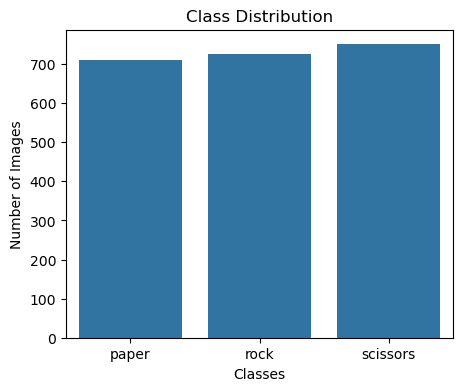

In [89]:
cls_info = {}

for cls in Classes:
    cls_info[cls] = len(os.listdir(dataset_path/cls))

plt.figure(figsize=(5,4))

sns.barplot(x=cls_info.keys(),y=cls_info.values())
plt.ylabel("Number of Images")
plt.xlabel("Classes")
plt.title("Class Distribution")

### show Random Images

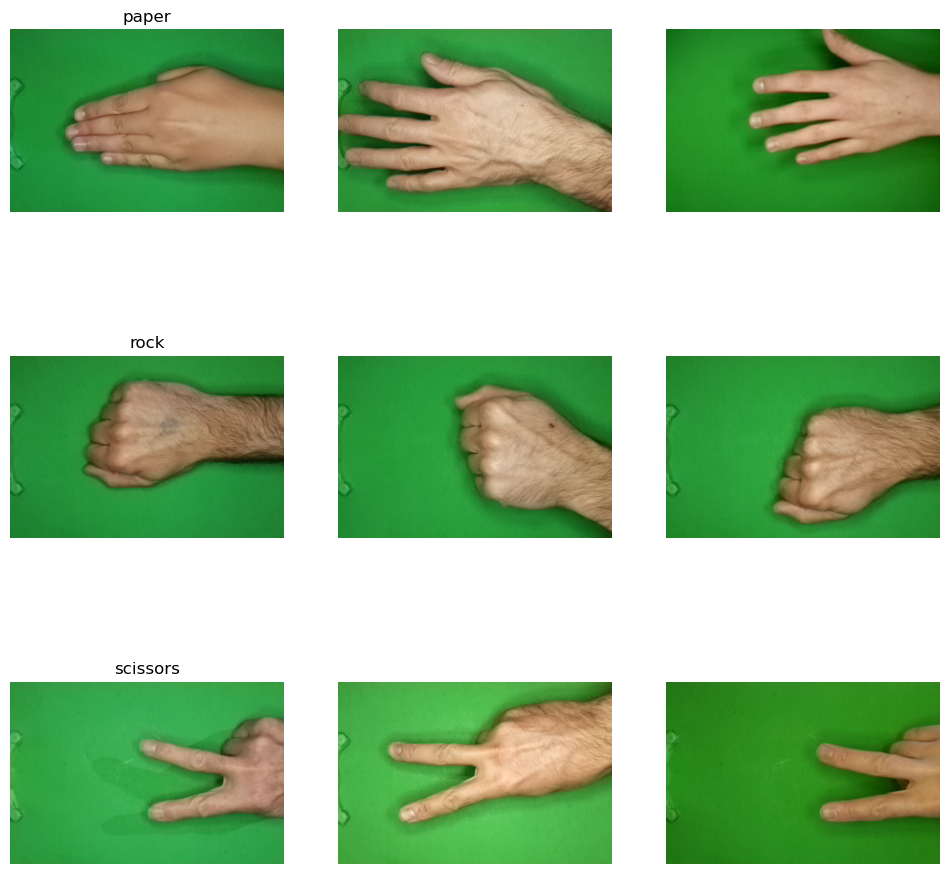

In [90]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, cls in enumerate(Classes):

    for col in range(3):

        img_name = random.choice(os.listdir(dataset_path / cls))

        img = cv2.imread(str(dataset_path / cls / img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row][col].imshow(img)
        axes[row][col].axis("off")

        if col == 0:
            axes[row][col].set_title(cls)

### Check Images Shapes

In [91]:
#shapes = []
#
#for cls in Classes:
#    for img_name in os.listdir(dataset_path/cls):
#        img = cv2.imread(str(dataset_path/cls/img_name))
#        
#        shapes.append(img.shape)

### So we should resize it to 128*128

In [92]:
#pd.Series(shapes).value_counts()

### Pixels Statistics

so min = 0 , max = 255 --> the intensity is normal distributed may be

Min : 0
Max : 255
Mean: 121.16509444444445
Std : 53.53446122143062


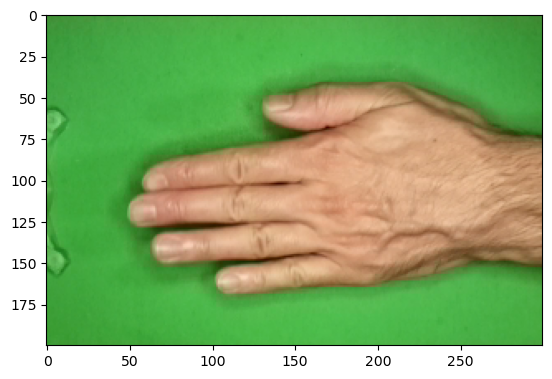

In [93]:
img_path = os.listdir(dataset_path/Classes[0])
img = cv2.imread(str(dataset_path/Classes[0]/img_path[0]))
img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
plt.imshow(img)


print("Min :", img.min())
print("Max :", img.max())
print("Mean:", img.mean())
print("Std :", img.std())


### Histogram for Pixels (Intensity)

the image is clearly and not need to use Histogram Equalization or CLACHE to fix Contrast Problem

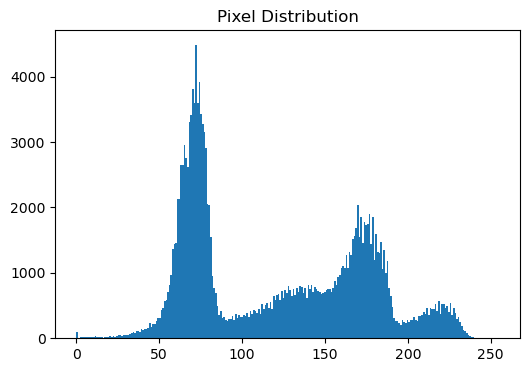

In [94]:
plt.figure(figsize=(6,4))

plt.hist(img.ravel(),
         bins=256)

plt.title("Pixel Distribution")

plt.show()

### Preprocessing Function 

In [95]:
def preprocessing_Gray(path):
    img = cv2.imread(str(path))
    
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    
    img = cv2.resize(img, (224, 224))
    
    img = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )
    
    img = np.expand_dims(img, axis=-1)
    
    return img


def preprocessing_RGB(path):
    img = cv2.imread(str(path))
    
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
    
    img = cv2.resize(img, (224, 224))
    
    return img



images = []
labels = []

classes = ['paper','rock','scissors']

for label, cls in enumerate(classes):
    
    folder = dataset_path/cls

    for filename in os.listdir(folder):

        path = os.path.join(folder, filename)

        img = preprocessing_RGB(path)

        images.append(img)
        labels.append(label)


images = np.array(images)
labels = np.array(labels)

print(images.shape)

(2187, 224, 224, 3)


<h1>Build Model

### split the Data

In [96]:
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.1,
    stratify=labels,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(1968, 224, 224, 3)
(219, 224, 224, 3)


### Data Augmentation and normalization

In [97]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

normalization = Rescaling(1./255)

### CNN

In [98]:
model = Sequential([

    Input(shape=(224,224,3)),

    data_augmentation,

    normalization,

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D(pool_size=(2,2)),


    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        units=128,
        activation="relu"
    ),
    BatchNormalization(),
    Dropout(0.3),

    Dense(
        units=3,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,331 (49.36 MB)

 Trainable params: 12,939,075 (49.36 MB)

 Non-trainable params: 256 (1.00 KB)

### Callbacks

In [99]:

callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),

    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True
    )

]

### Combile 

In [100]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the Model

In [101]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/30


KeyboardInterrupt: 

### Evlauate Model

In [ ]:
loss, accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=1
)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.3242 - loss: 5.3737
Validation Loss     : 5.3737
Validation Accuracy : 0.3242


### Predict the data

Load Model

In [110]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

In [111]:
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_true = y_val

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step


### Confusion Matrix

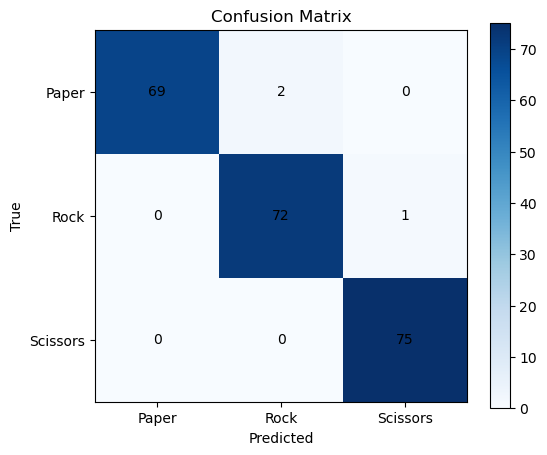

In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

classes = ["Paper", "Rock", "Scissors"]

plt.xticks(range(3), classes)
plt.yticks(range(3), classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.show()

### Classification Report

In [113]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Paper", "Rock", "Scissors"]
    )
)

              precision    recall  f1-score   support

       Paper       1.00      0.97      0.99        71
        Rock       0.97      0.99      0.98        73
    Scissors       0.99      1.00      0.99        75

    accuracy                           0.99       219
   macro avg       0.99      0.99      0.99       219
weighted avg       0.99      0.99      0.99       219



### Test Model

so the model is Perfect

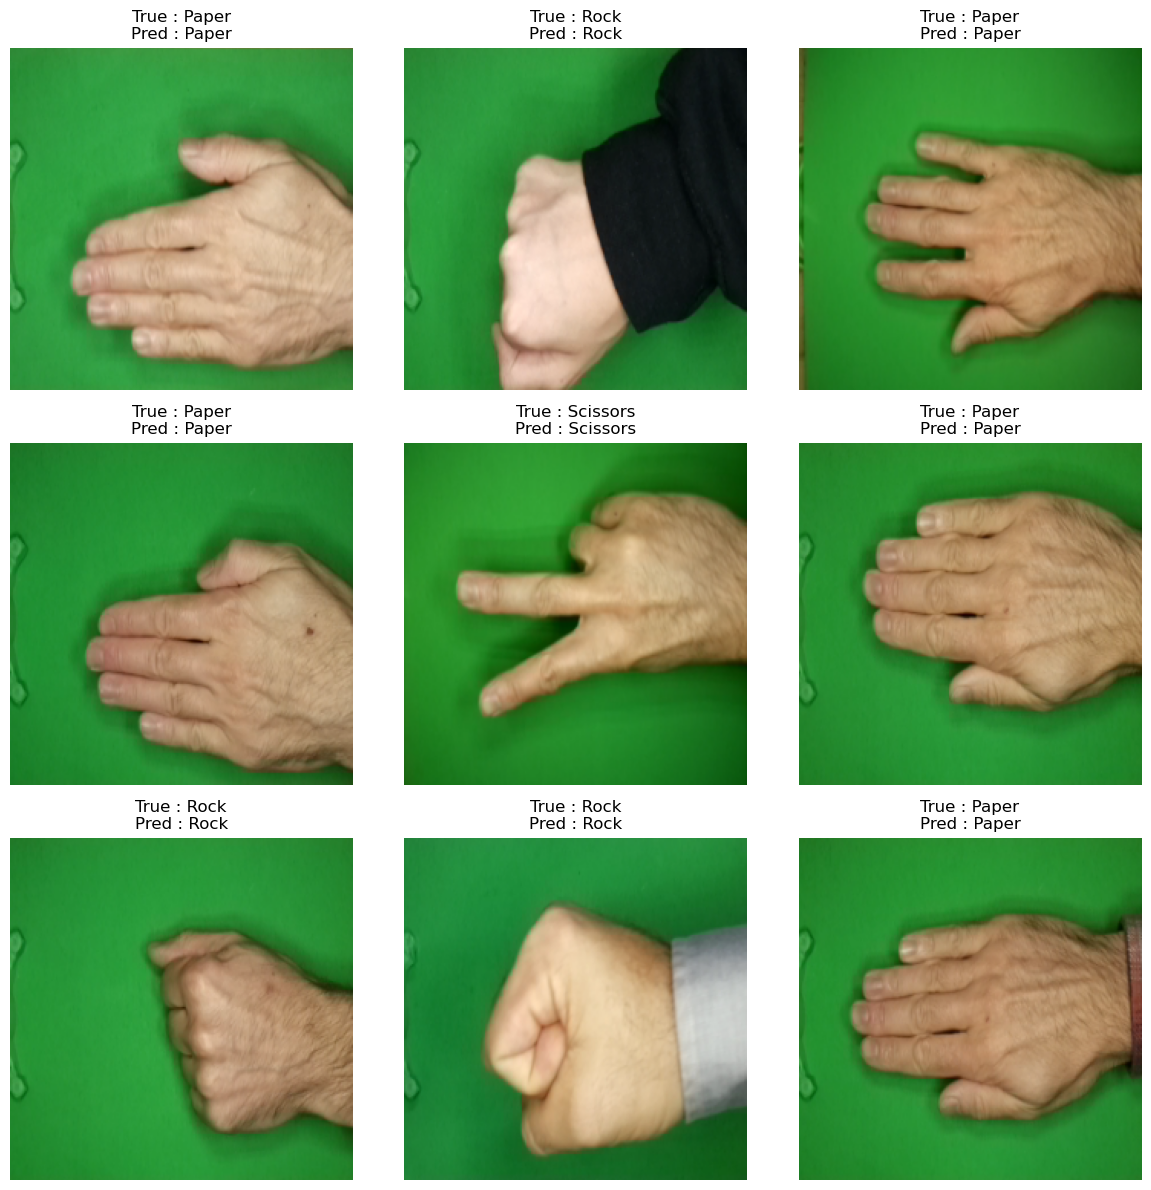

In [114]:
class_names = ["Paper", "Rock", "Scissors"]

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_val[i])

    plt.title(
        f"True : {class_names[y_true[i]]}\n"
        f"Pred : {class_names[y_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

<h1>Game Rule </h1>

In [115]:
def get_winner(left, right):

    if left == right:
        return "Draw"

    if (
        (left == "Rock" and right == "Scissors") or
        (left == "Paper" and right == "Rock") or
        (left == "Scissors" and right == "Paper")
    ):
        return "Left Player"

    return "Right Player"

### Preprocessing for ROI

In [116]:
def preprocessing_RGB(img):

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224,224))

    img = np.expand_dims(img, axis=0)

    return img

In [117]:
lower_skin = np.array([0, 20, 70], dtype=np.uint8)
upper_skin = np.array([20, 255, 255], dtype=np.uint8)

def green_background(roi):

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    mask = cv2.inRange(hsv, lower_skin, upper_skin)

    green = np.zeros_like(roi)
    green[:] = (0,255,0)

    hand = cv2.bitwise_and(
        roi,
        roi,
        mask=mask
    )

    background = cv2.bitwise_and(
        green,
        green,
        mask=cv2.bitwise_not(mask)
    )

    return cv2.add(hand, background)



### CAM and GUI

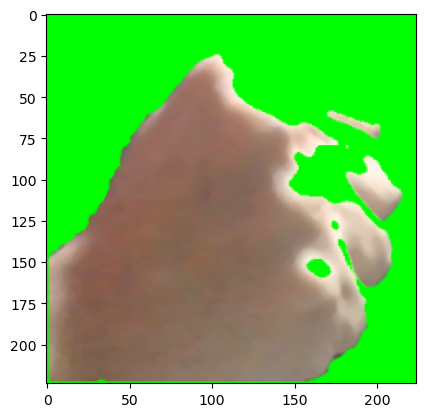

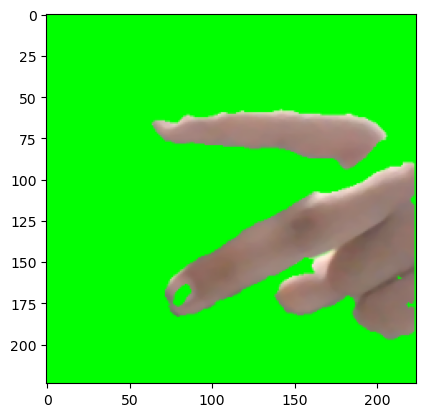

KeyboardInterrupt: 

In [121]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

# ===========================
# ROI Coordinates
# ===========================

LEFT_X1, LEFT_Y1 = 20, 80
LEFT_X2, LEFT_Y2 = 300, 360

RIGHT_X1, RIGHT_Y1 = 340, 80
RIGHT_X2, RIGHT_Y2 = 620, 360

classes = ["Paper", "Rock", "Scissors"]

left_move = ""
right_move = ""
winner = ""

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)

    # ===========================
    # UI
    # ===========================

    cv2.putText(
        frame,
        "Rock Paper Scissors",
        (130,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,255),
        2
    )

    cv2.putText(
        frame,
        "Player 1",
        (70,70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,255,255),
        2
    )

    cv2.putText(
        frame,
        "Player 2",
        (430,70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,255,255),
        2
    )

    # ===========================
    # Draw ROI
    # ===========================

    cv2.rectangle(
        frame,
        (LEFT_X1, LEFT_Y1),
        (LEFT_X2, LEFT_Y2),
        (0,255,0),
        2
    )

    cv2.rectangle(
        frame,
        (RIGHT_X1, RIGHT_Y1),
        (RIGHT_X2, RIGHT_Y2),
        (0,255,0),
        2
    )

    # ===========================
    # Crop ROI
    # ===========================

    left_roi = frame[LEFT_Y1:LEFT_Y2, LEFT_X1:LEFT_X2]
    right_roi = frame[RIGHT_Y1:RIGHT_Y2, RIGHT_X1:RIGHT_X2]

    # ===========================
    # Keyboard
    # ===========================

    key = cv2.waitKey(1) & 0xFF
    
    # ===========================
    # Green Background
    # ===========================
    left_roi_green = green_background(left_roi)
    right_roi_green = green_background(right_roi)
    
    left_roi_green = cv2.medianBlur(
    left_roi_green,
    5)

    right_roi_green = cv2.medianBlur(
    right_roi_green,
    5)
    

    # ===========================
    # Predict (SPACE)
    # ===========================

    if key == ord(" "):

        left_img = preprocessing_RGB(left_roi_green)
        right_img = preprocessing_RGB(right_roi_green)

        left_pred = model.predict(left_img, verbose=0)
        right_pred = model.predict(right_img, verbose=0)

        left_class = np.argmax(left_pred)
        right_class = np.argmax(right_pred)

        left_move = classes[left_class]
        right_move = classes[right_class]
        

        plt.imshow(left_img[0])
        plt.show()
        
        plt.imshow(right_img[0])
        plt.show()
        winner = get_winner(left_move, right_move)

    # ===========================
    # Restart (R)
    # ===========================

    if key == ord("r"):
        left_move = ""
        right_move = ""
        winner = ""

    # ===========================
    # Exit (Q)
    # ===========================

    if key == ord("q"):
        break

    # ===========================
    # Show Result
    # ===========================

    cv2.putText(
        frame,
        f"Player 1 : {left_move}",
        (20,420),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,255),
        2
    )

    cv2.putText(
        frame,
        f"Player 2 : {right_move}",
        (340,420),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,255),
        2
    )

    cv2.putText(
        frame,
        f"Winner : {winner}",
        (170,470),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,0,255),
        2
    )

    cv2.putText(
        frame,
        "SPACE = Predict | R = Restart | Q = Quit",
        (30,520),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,255),
        2
    )

    cv2.imshow("Rock Paper Scissors", frame)

cap.release()
cv2.destroyAllWindows()




Left Player
